# 13 t-test

Chapter 12 introduced hypothesis testing. We now apply that framework to differences involving **means** when the population standard deviation is unknown.

This chapter covers:

1. **One-sample t-test**
2. **Independent two-sample t-test (Welch)**
3. **Paired t-test**

## Learning Objectives

- choose a t-test from the research design;
- formulate $H_0$ and $H_1$;
- understand and calculate t-statistics;
- perform t-tests with SciPy;
- interpret p-values with confidence intervals and effect sizes;
- understand assumptions and practical limitations.

## 1. Core Idea

The general structure is:

$$
t=\frac{\text{Observed Difference}-\text{Difference Under }H_0}{\text{Estimated Standard Error}}
$$

A larger $|t|$ means the observed difference is larger relative to sampling uncertainty.

| Design | Appropriate Test |
|---|---|
| One sample vs benchmark | One-sample t-test |
| Two unrelated groups | Independent t-test |
| Same subjects twice / matched pairs | Paired t-test |

**Choose the test from the study design—not from which test gives the smallest p-value.**

## 2. Dataset

`13_t_test.csv` combines three fictional educational scenarios.

- `one_sample`: processing time compared with a 30-minute benchmark
- `independent`: separate groups using Method A and Method B
- `paired`: the same participants measured before and after

Missing values are intentional because each scenario uses different columns.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

cwd=Path.cwd().resolve()
root=next((p for p in [cwd,*cwd.parents] if (p/"data").is_dir()),None)
if root is None: raise FileNotFoundError("Could not find project root containing data/.")
df=pd.read_csv(root/"data"/"13_t_test.csv")
df.groupby(["analysis_type","group"]).size()

analysis_type  group            
independent    Method_A             35
               Method_B             38
one_sample     Current_Process      40
paired         Same_Participants    30
dtype: int64

# Part A — One-Sample t-test

## 3. Research Question

Compare the current process with:

$$\mu_0=30$$

minutes.

$$H_0:\mu=30$$

$$H_1:\mu\neq30$$

In [3]:
one=df.loc[df["analysis_type"]=="one_sample","value"].dropna()
n=len(one); x_bar=one.mean(); s=one.std(ddof=1); mu_0=30
print(f"n={n}, x̄={x_bar:.2f}, s={s:.2f}")

n=40, x̄=32.22, s=4.79


## 4. Manual Calculation

$$
t=\frac{\bar{x}-\mu_0}{s/\sqrt{n}},\qquad df=n-1
$$

In [4]:
se=s/np.sqrt(n)
t_manual=(x_bar-mu_0)/se
print(f"SE={se:.3f}, t={t_manual:.3f}, df={n-1}")

SE=0.757, t=2.931, df=39


## 5. SciPy One-Sample Test

In [5]:
r1=stats.ttest_1samp(one,popmean=mu_0)
print(f"t={r1.statistic:.3f}")
print(f"p={r1.pvalue:.6f}")

t=2.931
p=0.005618


## 6. Confidence Interval and Effect Size

For the mean:

$$\bar{x}\pm t^*\frac{s}{\sqrt{n}}$$

A simple standardized difference is:

$$d=\frac{\bar{x}-\mu_0}{s}$$

The p-value addresses evidence against the null model; the confidence interval and effect size help describe uncertainty and magnitude.

In [6]:
critical=stats.t.ppf(.975,df=n-1)
margin=critical*se
print(f"95% CI for mean: ({x_bar-margin:.2f}, {x_bar+margin:.2f})")
print(f"Cohen's d: {(x_bar-mu_0)/s:.3f}")

95% CI for mean: (30.69, 33.75)
Cohen's d: 0.464


# Part B — Independent Two-Sample t-test

## 7. Research Question

Method A and Method B contain **different participants**.

$$H_0:\mu_A-\mu_B=0$$

$$H_1:\mu_A-\mu_B\neq0$$

In [7]:
ind=df[df["analysis_type"]=="independent"]
a=ind.loc[ind["group"]=="Method_A","value"].dropna()
b=ind.loc[ind["group"]=="Method_B","value"].dropna()
pd.DataFrame({"Method_A":[len(a),a.mean(),a.std(ddof=1)],
              "Method_B":[len(b),b.mean(),b.std(ddof=1)]},
             index=["n","mean","sd"])

,Method_A,Method_B
n,35.000000,38.000000
mean,71.942857,75.252632
sd,6.080552,5.977694


## 8. Inspect the Groups First

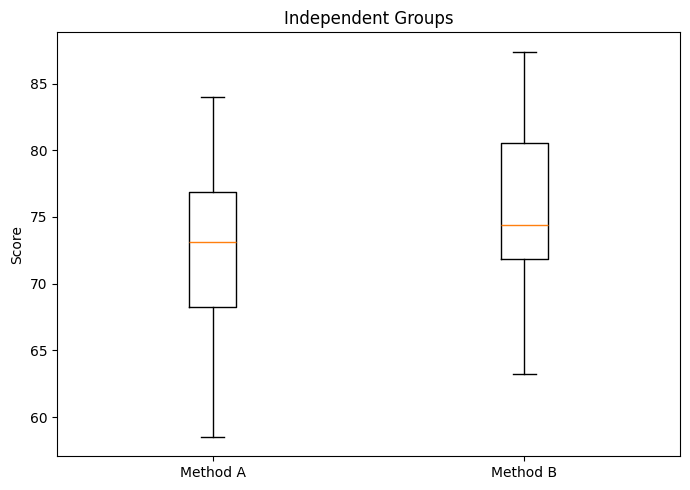

In [8]:
plt.figure(figsize=(7,5))
plt.boxplot([a,b],tick_labels=["Method A","Method B"])
plt.title("Independent Groups")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## 9. Welch's t-test

The classic Student two-sample t-test assumes equal population variances. **Welch's t-test** does not require that assumption and is often a sensible default for independent groups.

In SciPy:

```python
stats.ttest_ind(a, b, equal_var=False)
```

In [9]:
r2=stats.ttest_ind(a,b,equal_var=False)
diff=a.mean()-b.mean()
print(f"Mean A={a.mean():.2f}, Mean B={b.mean():.2f}")
print(f"A-B={diff:.2f}")
print(f"Welch t={r2.statistic:.3f}, p={r2.pvalue:.6f}")

Mean A=71.94, Mean B=75.25
A-B=-3.31
Welch t=-2.342, p=0.022003


## 10. Welch Confidence Interval

$$
SE=\sqrt{\frac{s_A^2}{n_A}+\frac{s_B^2}{n_B}}
$$

Welch's degrees of freedom account for unequal sample variances and need not be an integer.

In [10]:
na,nb=len(a),len(b); va,vb=a.var(ddof=1),b.var(ddof=1)
sew=np.sqrt(va/na+vb/nb)
dfw=(va/na+vb/nb)**2/((va/na)**2/(na-1)+(vb/nb)**2/(nb-1))
crit=stats.t.ppf(.975,df=dfw)
print(f"Welch df={dfw:.2f}")
print(f"95% CI for A-B: ({diff-crit*sew:.2f}, {diff+crit*sew:.2f})")

Welch df=70.29
95% CI for A-B: (-6.13, -0.49)


## 11. Independent-Groups Effect Size

One descriptive standardized mean difference is:

$$
d=\frac{\bar{x}_A-\bar{x}_B}{s_p}
$$

where $s_p$ is the pooled sample standard deviation. This effect-size calculation is descriptive; our inferential test remains Welch's test.

In [11]:
pooled=np.sqrt(((na-1)*va+(nb-1)*vb)/(na+nb-2))
print(f"Cohen's d={diff/pooled:.3f}")

Cohen's d=-0.549


# Part C — Paired t-test

## 12. Research Question

The **same participants** are measured before and after.

Define:

$$D_i=After_i-Before_i$$

Then:

$$H_0:\mu_D=0$$

$$H_1:\mu_D\neq0$$

A paired t-test is essentially a one-sample t-test on the within-pair differences.

In [12]:
paired=df[df["analysis_type"]=="paired"].copy()
before=paired["before_score"]; after=paired["after_score"]
d=after-before
print(f"n={len(d)}")
print(f"Before mean={before.mean():.2f}")
print(f"After mean={after.mean():.2f}")
print(f"Mean change={d.mean():.2f}")

n=30
Before mean=64.95
After mean=69.60
Mean change=4.64


## 13. Visualize the Pairing

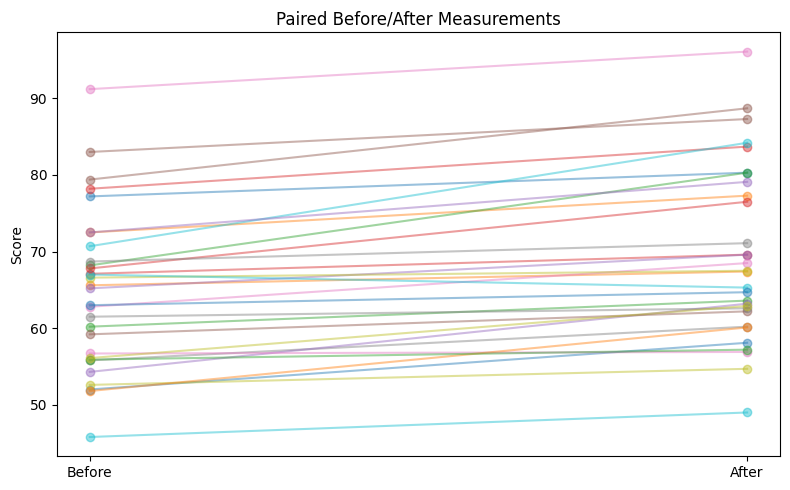

In [13]:
plt.figure(figsize=(8,5))
for _,row in paired.iterrows():
    plt.plot(["Before","After"],[row["before_score"],row["after_score"]],marker="o",alpha=.45)
plt.title("Paired Before/After Measurements")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## 14. Paired t-test with SciPy

In [14]:
r3=stats.ttest_rel(after,before)
print(f"Paired t={r3.statistic:.3f}")
print(f"p={r3.pvalue:.6f}")

Paired t=7.262
p=0.000000


## 15. Verify the Logic Manually

$$
t=\frac{\bar{D}}{s_D/\sqrt{n}}
$$

In [15]:
npair=len(d); md=d.mean(); sd=d.std(ddof=1); sed=sd/np.sqrt(npair)
print(f"Mean difference={md:.3f}")
print(f"SD differences={sd:.3f}")
print(f"Manual t={md/sed:.3f}")

Mean difference=4.643
SD differences=3.502
Manual t=7.262


## 16. Paired Confidence Interval and Effect Size

$$
\bar{D}\pm t^*\frac{s_D}{\sqrt{n}}
$$

A paired standardized effect can be written:

$$d_z=\frac{\bar{D}}{s_D}$$

In [16]:
critp=stats.t.ppf(.975,df=npair-1)
print(f"95% CI for mean change: ({md-critp*sed:.2f}, {md+critp*sed:.2f})")
print(f"Paired effect size dz={md/sd:.3f}")

95% CI for mean change: (3.34, 5.95)
Paired effect size dz=1.326


# Part D — Interpretation

## 17. Assumptions

### One-sample
- quantitative outcome;
- observations sufficiently independent for the procedure;
- severe outliers can be problematic, especially for small samples;
- the sampling behavior of the mean should be reasonably handled by the t procedure.

### Independent
- the two groups are independent;
- observations within groups are sufficiently independent;
- quantitative outcome;
- Welch's test does **not** require equal population variances.

### Paired
- observations are genuinely matched;
- different pairs are sufficiently independent;
- the relevant distribution for the t procedure is the distribution of **within-pair differences**.

Always inspect study design and data quality before focusing on the p-value.

## 18. Statistical Significance Is Not Enough

A useful report should consider:

- sample sizes;
- means and mean differences;
- variability;
- confidence interval;
- t-statistic and degrees of freedom;
- p-value;
- effect size;
- practical context.

A statistically significant result is not automatically a practically important result.

## 19. Practical Decision Guide

**One sample vs one benchmark?**  
→ One-sample t-test

**Two separate groups?**  
→ Independent t-test; Welch's test is commonly useful.

**Same subjects twice / matched pairs?**  
→ Paired t-test

The design determines the test.

## Exercises

1. Change the one-sample benchmark from 30 to 31 and compare the result.
2. Reproduce the one-sample t-statistic manually.
3. Calculate and interpret the Method A − Method B confidence interval.
4. Compare `equal_var=True` and `equal_var=False` for the independent groups.
5. Plot the paired change scores.
6. Confirm that `ttest_rel(after, before)` matches `ttest_1samp(after-before, 0)`.
7. Explain why treating paired data as independent can waste information.
8. Choose the appropriate t-test for: one battery-life claim, two separate classes, and the same people's before/after blood pressure.
9. Write a short report including estimate, CI, p-value, and effect size.

## Summary

The t-test family applies Chapter 12's hypothesis-testing framework to means:

$$
\text{Research Design}
\rightarrow
\text{Choose t-test}
\rightarrow
H_0/H_1
\rightarrow
t
\rightarrow
p
\rightarrow
\text{CI + Effect Size}
\rightarrow
\text{Interpretation}
$$

You learned:

- **One-sample t-test** — one mean vs a benchmark;
- **Welch's independent t-test** — two unrelated groups;
- **Paired t-test** — matched or repeated observations.

> **Choose the test from the research design, then interpret statistical evidence together with magnitude, uncertainty, and context.**

Next:

# 14 Chi-Square Test

We move from quantitative means to inference involving **categorical variables**.